### This notebook uses the engineered monthly airline-airport dataset created in the previous preprocessing notebook and focuses on predictive modeling of high-disruption months.

# Imports

In [108]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import streamlit as st

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load the dataset

In [2]:
# Load the final modeling dataset
model_df = pd.read_parquet("../data/processed/modeling_dataset.parquet")

# Convert YearMonth to datetime
model_df['YearMonth'] = pd.to_datetime(model_df['YearMonth'])

# Preview the dataset
model_df.head()

,YearMonth,Reporting_Airline,Origin,total_completed_flights,dep_delayed_flights,arr_delayed_flights,disrupted_flights,avg_dep_delay,avg_arr_delay,median_dep_delay,...,rolling_3_std_total_scheduled_flights,airline_prev_pct_disrupted,airline_prev_pct_cancelled,airport_prev_pct_disrupted,airport_prev_pct_cancelled,interaction_disruption_delay,interaction_disruption_cancel,interaction_volume_delay,month_num,quarter
0,2023-07-01,9E,ABE,85,12,11,14,10.894118,7.258824,-3.0,...,36.755952,0.209302,0.000000,0.209302,0.000000,-0.051109,0.000000,-21.000000,7,3
1,2023-08-01,9E,ABE,86,17,18,19,21.290698,15.523256,-4.0,...,10.969655,0.164706,0.011628,0.164706,0.011628,1.195571,0.001915,624.258824,8,3
2,2023-09-01,9E,ABE,80,8,7,8,5.062500,-3.250000,-5.0,...,1.732051,0.220930,0.022472,0.220930,0.022472,3.429557,0.004965,1381.569767,9,3
3,2023-10-01,9E,ABE,86,2,2,3,-3.988372,-19.872093,-5.0,...,4.582576,0.100000,0.000000,0.100000,0.000000,-0.325000,0.000000,-260.000000,10,4
4,2023-11-01,9E,ABE,76,4,6,7,3.263158,-12.986842,-5.0,...,4.582576,0.034884,0.000000,0.034884,0.000000,-0.693213,0.000000,-1709.000000,11,4


# Create the Final Modeling Dataset

## Create a Fresh Copy for Modeling

In [3]:
# Create a fresh copy of the engineered dataset for modeling
final_model_df = model_df.copy()

# Preview the dataset
final_model_df.head()

,YearMonth,Reporting_Airline,Origin,total_completed_flights,dep_delayed_flights,arr_delayed_flights,disrupted_flights,avg_dep_delay,avg_arr_delay,median_dep_delay,...,rolling_3_std_total_scheduled_flights,airline_prev_pct_disrupted,airline_prev_pct_cancelled,airport_prev_pct_disrupted,airport_prev_pct_cancelled,interaction_disruption_delay,interaction_disruption_cancel,interaction_volume_delay,month_num,quarter
0,2023-07-01,9E,ABE,85,12,11,14,10.894118,7.258824,-3.0,...,36.755952,0.209302,0.000000,0.209302,0.000000,-0.051109,0.000000,-21.000000,7,3
1,2023-08-01,9E,ABE,86,17,18,19,21.290698,15.523256,-4.0,...,10.969655,0.164706,0.011628,0.164706,0.011628,1.195571,0.001915,624.258824,8,3
2,2023-09-01,9E,ABE,80,8,7,8,5.062500,-3.250000,-5.0,...,1.732051,0.220930,0.022472,0.220930,0.022472,3.429557,0.004965,1381.569767,9,3
3,2023-10-01,9E,ABE,86,2,2,3,-3.988372,-19.872093,-5.0,...,4.582576,0.100000,0.000000,0.100000,0.000000,-0.325000,0.000000,-260.000000,10,4
4,2023-11-01,9E,ABE,76,4,6,7,3.263158,-12.986842,-5.0,...,4.582576,0.034884,0.000000,0.034884,0.000000,-0.693213,0.000000,-1709.000000,11,4


## Select Numeric and Categorical Features

In [4]:
# Define the numeric features for modeling
numeric_features = [
    'lag_1_pct_disrupted', 'lag_2_pct_disrupted', 'lag_3_pct_disrupted',
    'lag_1_pct_cancelled', 'lag_2_pct_cancelled', 'lag_3_pct_cancelled',
    'lag_1_pct_diverted', 'lag_2_pct_diverted', 'lag_3_pct_diverted',
    'lag_1_avg_dep_delay', 'lag_2_avg_dep_delay', 'lag_3_avg_dep_delay',
    'lag_1_avg_arr_delay', 'lag_2_avg_arr_delay', 'lag_3_avg_arr_delay',
    'delta_pct_disrupted', 'delta_pct_cancelled', 'delta_pct_diverted',
    'delta_avg_dep_delay', 'delta_avg_arr_delay', 'delta2_pct_disrupted', 
    'delta2_pct_cancelled', 'delta2_avg_arr_delay','rolling_3_pct_disrupted', 
    'rolling_3_pct_cancelled', 'rolling_3_avg_dep_delay', 'rolling_3_avg_arr_delay',
    'rolling_3_std_pct_disrupted', 'rolling_3_std_pct_cancelled',
    'rolling_3_std_avg_dep_delay', 'rolling_3_std_avg_arr_delay',
    'lag_1_total_scheduled_flights', 'lag_2_total_scheduled_flights',
    'lag_3_total_scheduled_flights', 'delta_total_scheduled_flights',
    'rolling_3_total_scheduled_flights', 'rolling_3_std_total_scheduled_flights',
    'airline_prev_pct_disrupted', 'airline_prev_pct_cancelled', 'airport_prev_pct_disrupted',
    'airport_prev_pct_cancelled', 'interaction_disruption_delay', 'interaction_disruption_cancel',
    'interaction_volume_delay', 'month_num', 'quarter'
]

# Define the categorical features for modeling
categorical_features = [
    'Reporting_Airline',
    'Origin'
]

# Define the target column
target_col = 'HighDisruptionMonth'

# Display the feature groups
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target column:", target_col)

Numeric features: ['lag_1_pct_disrupted', 'lag_2_pct_disrupted', 'lag_3_pct_disrupted', 'lag_1_pct_cancelled', 'lag_2_pct_cancelled', 'lag_3_pct_cancelled', 'lag_1_pct_diverted', 'lag_2_pct_diverted', 'lag_3_pct_diverted', 'lag_1_avg_dep_delay', 'lag_2_avg_dep_delay', 'lag_3_avg_dep_delay', 'lag_1_avg_arr_delay', 'lag_2_avg_arr_delay', 'lag_3_avg_arr_delay', 'delta_pct_disrupted', 'delta_pct_cancelled', 'delta_pct_diverted', 'delta_avg_dep_delay', 'delta_avg_arr_delay', 'delta2_pct_disrupted', 'delta2_pct_cancelled', 'delta2_avg_arr_delay', 'rolling_3_pct_disrupted', 'rolling_3_pct_cancelled', 'rolling_3_avg_dep_delay', 'rolling_3_avg_arr_delay', 'rolling_3_std_pct_disrupted', 'rolling_3_std_pct_cancelled', 'rolling_3_std_avg_dep_delay', 'rolling_3_std_avg_arr_delay', 'lag_1_total_scheduled_flights', 'lag_2_total_scheduled_flights', 'lag_3_total_scheduled_flights', 'delta_total_scheduled_flights', 'rolling_3_total_scheduled_flights', 'rolling_3_std_total_scheduled_flights', 'airline_pr

## Create the Final Modeling Table

In [5]:
# Keep only the selected features and target column
final_model_df = final_model_df[
    numeric_features + categorical_features + [target_col, 'YearMonth']
].copy()

# Display the shape of the final modeling table
final_model_df.shape

(49575, 50)

## Check Missing Values

In [6]:
# Check for missing values in the final modeling table
final_model_df.isnull().sum()

lag_1_pct_disrupted                      0
lag_2_pct_disrupted                      0
lag_3_pct_disrupted                      0
lag_1_pct_cancelled                      0
lag_2_pct_cancelled                      0
lag_3_pct_cancelled                      0
lag_1_pct_diverted                       0
lag_2_pct_diverted                       0
lag_3_pct_diverted                       0
lag_1_avg_dep_delay                      0
lag_2_avg_dep_delay                      0
lag_3_avg_dep_delay                      0
lag_1_avg_arr_delay                      0
lag_2_avg_arr_delay                      0
lag_3_avg_arr_delay                      0
delta_pct_disrupted                      0
delta_pct_cancelled                      0
delta_pct_diverted                       0
delta_avg_dep_delay                      0
delta_avg_arr_delay                      0
delta2_pct_disrupted                     0
delta2_pct_cancelled                     0
delta2_avg_arr_delay                     0
rolling_3_p

## Save the Final Modeling Table

In [7]:
# Save the reduced working dataset to the processed data folder
final_model_df.to_parquet("../data/processed/final_modeling_data.parquet", index=False)

# Print confirmation message
print("Final modeling dataset has been saved successfully.")

Final modeling dataset has been saved successfully.


# Create Two Separate Containers

In [8]:
baseline_results = []
tuned_results = []

# Create a Time-Based Train-Test Split


## Split into Training and Test Sets

In [9]:
# Create time-based training and test sets
train_df = final_model_df[final_model_df['YearMonth'] < '2025-01-01'].copy()
test_df = final_model_df[final_model_df['YearMonth'] >= '2025-01-01'].copy()

# Display the shapes of the training and test sets
print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

Training set shape: (31975, 50)
Test set shape: (17600, 50)


## Check Target Distribution

In [10]:
# Check the target distribution in the training set
print("Training target distribution:")
print(train_df[target_col].value_counts())

# Check the target distribution in the test set
print("\nTest target distribution:")
print(test_df[target_col].value_counts())

Training target distribution:
HighDisruptionMonth
0    24729
1     7246
Name: count, dtype: int64

Test target distribution:
HighDisruptionMonth
0    12597
1     5003
Name: count, dtype: int64


## Create x and y

In [11]:
# Create training and test feature matrices
X_train = train_df[numeric_features + categorical_features].copy()
X_test = test_df[numeric_features + categorical_features].copy()

# Create training and test target vectors
y_train = train_df[target_col].copy()
y_test = test_df[target_col].copy()

# Display the shapes of the feature matrices
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (31975, 48)
X_test shape: (17600, 48)


# Create a Baseline Prediction

## Baseline Rule

In [12]:
# Define the disruption threshold used to create the target variable
disruption_threshold = 0.2990

In [13]:
# Create a baseline prediction using the previous month's disruption rate
baseline_preds = (X_test['lag_1_pct_disrupted'] > disruption_threshold).astype(int)

# Check the baseline prediction distribution
baseline_preds.value_counts()

lag_1_pct_disrupted
0    12909
1     4691
Name: count, dtype: int64

## Evaluate the Baseline Model

In [14]:
# Print baseline classification metrics
print("Baseline Accuracy:", accuracy_score(y_test, baseline_preds))
print("Baseline Precision:", precision_score(y_test, baseline_preds, zero_division=0))
print("Baseline Recall:", recall_score(y_test, baseline_preds, zero_division=0))
print("Baseline F1 Score:", f1_score(y_test, baseline_preds, zero_division=0))

# Display the confusion matrix
confusion_matrix(y_test, baseline_preds)

Baseline Accuracy: 0.7490909090909091
Baseline Precision: 0.5625666169260286
Baseline Recall: 0.5274835098940636
Baseline F1 Score: 0.5444604910253765


array([[10545,  2052],
       [ 2364,  2639]])

# Create the Preprocessor

In [15]:
# Create a preprocessing pipeline for numeric features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create a preprocessing pipeline for categorical features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine numeric and categorical preprocessing steps
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Train Logistic Regression

## Build the Logistic Regression Pipeline

In [16]:
# Create the logistic regression modeling pipeline
log_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Fit the logistic regression model
log_reg_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate Logistic Regression Predictions

In [17]:
# Generate predicted classes and probabilities for logistic regression
log_reg_preds_before = log_reg_pipeline.predict(X_test)
log_reg_probs_before = log_reg_pipeline.predict_proba(X_test)[:, 1]

## Evaluate Logistic Regression

In [18]:
# Print logistic regression evaluation metrics
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_reg_preds_before))
print("Logistic Regression Precision:", precision_score(y_test, log_reg_preds_before, zero_division=0))
print("Logistic Regression Recall:", recall_score(y_test, log_reg_preds_before, zero_division=0))
print("Logistic Regression F1 Score:", f1_score(y_test, log_reg_preds_before, zero_division=0))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, log_reg_probs_before))

# Display the confusion matrix
confusion_matrix(y_test, log_reg_preds_before)

Logistic Regression Accuracy: 0.6853977272727273
Logistic Regression Precision: 0.46310116086235487
Logistic Regression Recall: 0.6697981211273236
Logistic Regression F1 Score: 0.5475937576599396
Logistic Regression ROC-AUC: 0.7395388598388162


array([[8712, 3885],
       [1652, 3351]])

## Print the Classification Report

In [19]:
# Print the full classification report for logistic regression
print(classification_report(y_test, log_reg_preds_before, zero_division=0))

              precision    recall  f1-score   support

           0       0.84      0.69      0.76     12597
           1       0.46      0.67      0.55      5003

    accuracy                           0.69     17600
   macro avg       0.65      0.68      0.65     17600
weighted avg       0.73      0.69      0.70     17600



## Store Logistic Regression Baseline Results

In [20]:
baseline_results.append({
    'Model': 'Logistic Regression',
    'Stage': 'Baseline',
    'AUC': roc_auc_score(y_test, log_reg_probs_before),
    'F1': f1_score(y_test, log_reg_preds_before),
    'Recall': recall_score(y_test, log_reg_preds_before),
    'Precision': precision_score(y_test, log_reg_preds_before),
    'Accuracy': accuracy_score(y_test, log_reg_preds_before)
})

# Tuning Logistic Regression

## Create a validation split from training data

In [21]:
# Sorting 
train_df = train_df.sort_values('YearMonth')

# Define validation cutoff within TRAIN data (2024)
val_cutoff = '2024-10-01'   # last 3 months of 2024 for validation

# Split training data into train_sub and val_sub (time-based)
train_sub = train_df[train_df['YearMonth'] < val_cutoff]
val_sub = train_df[train_df['YearMonth'] >= val_cutoff]

# Define features
X_train_sub = train_sub[numeric_features + categorical_features]
y_train_sub = train_sub[target_col]

X_val = val_sub[numeric_features + categorical_features]
y_val = val_sub[target_col]

print("Train_sub shape:", X_train_sub.shape)
print("Validation shape:", X_val.shape)

Train_sub shape: (27341, 48)
Validation shape: (4634, 48)


## Define parameter grid

In [22]:
param_grid = [
    {'C': 0.001, 'penalty': 'l2'},
    {'C': 0.01, 'penalty': 'l2'},
    {'C': 0.1, 'penalty': 'l2'},
    {'C': 1.0, 'penalty': 'l2'},
    {'C': 10.0, 'penalty': 'l2'},
    {'C': 0.01, 'penalty': 'l1'},
    {'C': 0.1, 'penalty': 'l1'},
    {'C': 1.0, 'penalty': 'l1'},
    {'C': 10.0, 'penalty': 'l1'}
]

## Manual tuning loop

In [23]:
# Create variables to store the best results
best_auc = 0
best_f1 = 0
best_recall = 0
best_params = None

# Create a list to store tuning results
tuning_results = []

for params in param_grid:
    
    # Choose solver based on penalty type
    if params['penalty'] == 'l1':
        solver = 'liblinear'
    else:
        solver = 'lbfgs'
    
    # Build the logistic regression pipeline
    log_reg_model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            C=params['C'],
            penalty=params['penalty'],
            solver=solver,
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ])
    
    # Fit the model on the sub-training data
    log_reg_model.fit(X_train_sub, y_train_sub)
    
    # Generate validation probabilities
    val_probs = log_reg_model.predict_proba(X_val)[:, 1]
    
    # Generate validation predictions using default threshold
    val_preds = (val_probs >= 0.5).astype(int)
    
    # Calculate validation metrics
    val_auc = roc_auc_score(y_val, val_probs)
    val_f1 = f1_score(y_val, val_preds, zero_division=0)
    val_recall = recall_score(y_val, val_preds, zero_division=0)
    
    # Save results
    tuning_results.append({
        'C': params['C'],
        'penalty': params['penalty'],
        'AUC': val_auc,
        'F1': val_f1,
        'Recall': val_recall
    })
    
    # Print results
    print(f"{params} | AUC: {val_auc:.4f}, F1: {val_f1:.4f}, Recall: {val_recall:.4f}")
    
    # Keep the best parameter set based on AUC
    if val_auc > best_auc:
        best_auc = val_auc
        best_f1 = val_f1
        best_recall = val_recall
        best_params = params

# Convert results to dataframe
tuning_results_df = pd.DataFrame(tuning_results).sort_values(by='AUC', ascending=False).reset_index(drop=True)

# Display the tuning results table
tuning_results_df

{'C': 0.001, 'penalty': 'l2'} | AUC: 0.6800, F1: 0.3031, Recall: 0.2536
{'C': 0.01, 'penalty': 'l2'} | AUC: 0.6816, F1: 0.3048, Recall: 0.2779
{'C': 0.1, 'penalty': 'l2'} | AUC: 0.6820, F1: 0.3123, Recall: 0.3080
{'C': 1.0, 'penalty': 'l2'} | AUC: 0.6857, F1: 0.3198, Recall: 0.3281
{'C': 10.0, 'penalty': 'l2'} | AUC: 0.6856, F1: 0.3211, Recall: 0.3324
{'C': 0.01, 'penalty': 'l1'} | AUC: 0.6746, F1: 0.3064, Recall: 0.2607
{'C': 0.1, 'penalty': 'l1'} | AUC: 0.6747, F1: 0.3010, Recall: 0.2865
{'C': 1.0, 'penalty': 'l1'} | AUC: 0.6841, F1: 0.3197, Recall: 0.3252
{'C': 10.0, 'penalty': 'l1'} | AUC: 0.6857, F1: 0.3220, Recall: 0.3338


,C,penalty,AUC,F1,Recall
0,10.000,l1,0.685716,0.322046,0.333811
1,1.000,l2,0.685653,0.319832,0.328080
2,10.000,l2,0.685641,0.321107,0.332378
3,1.000,l1,0.684113,0.319718,0.325215
4,0.100,l2,0.681980,0.312273,0.308023
5,0.010,l2,0.681591,0.304792,0.277937
6,0.001,l2,0.679953,0.303082,0.253582
7,0.100,l1,0.674700,0.300978,0.286533
8,0.010,l1,0.674558,0.306397,0.260745


## Refit the best model on train_sub only

In [24]:
# Choose the best solver based on the selected penalty
if best_params['penalty'] == 'l1':
    best_solver = 'liblinear'
else:
    best_solver = 'lbfgs'

# Build the best logistic regression pipeline
best_log_reg_val = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        C=best_params['C'],
        penalty=best_params['penalty'],
        solver=best_solver,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

# Fit on train_sub only
best_log_reg_val.fit(X_train_sub, y_train_sub)

# Generate validation probabilities
val_probs = best_log_reg_val.predict_proba(X_val)[:, 1]

## Choose the best threshold on validation data

In [25]:
# Search for the best threshold on validation data using F1 score
thresholds = np.arange(0.05, 0.5, 0.01)

best_threshold = 0.5
best_val_f1 = 0

for t in thresholds:
    val_preds = (val_probs >= t).astype(int)
    val_f1 = f1_score(y_val, val_preds, zero_division=0)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_threshold = t

print("Best Validation Threshold:", best_threshold)
print("Best Validation F1:", best_val_f1)

Best Validation Threshold: 0.28
Best Validation F1: 0.3431952662721893


In [26]:
# Check validation recall at the best threshold
best_val_preds = (val_probs >= best_threshold).astype(int)

print("Validation Precision:", precision_score(y_val, best_val_preds, zero_division=0))
print("Validation Recall:", recall_score(y_val, best_val_preds, zero_division=0))
print("Validation F1:", f1_score(y_val, best_val_preds, zero_division=0))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_probs))

Validation Precision: 0.2434052757793765
Validation Recall: 0.5816618911174785
Validation F1: 0.3431952662721893
Validation ROC-AUC: 0.6857157208749738


## Retrain the model on the full training data

In [27]:
# Build the final logistic regression pipeline
best_log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        C=best_params['C'],
        penalty=best_params['penalty'],
        solver=best_solver,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

# Fit on the full training data
best_log_reg.fit(X_train, y_train)

# Generate test probabilities
log_reg_probs = best_log_reg.predict_proba(X_test)[:, 1]

## Create predictions using that threshold

In [28]:
# Create final predictions using tuned threshold
log_reg_preds = (log_reg_probs >= best_threshold).astype(int)

## Evaluate Tuned Logistic Regression Model

In [29]:
# Print tuned logistic regression evaluation metrics
print("Tuned Logistic Regression Accuracy:", accuracy_score(y_test, log_reg_preds))
print("Tuned Logistic Regression Precision:", precision_score(y_test, log_reg_preds, zero_division=0))
print("Tuned Logistic Regression Recall:", recall_score(y_test, log_reg_preds, zero_division=0))
print("Tuned Logistic Regression F1 Score:", f1_score(y_test, log_reg_preds, zero_division=0))
print("Tuned Logistic Regression ROC-AUC:", roc_auc_score(y_test, log_reg_probs))

# Display the confusion matrix
confusion_matrix(y_test, log_reg_preds)

Tuned Logistic Regression Accuracy: 0.515
Tuned Logistic Regression Precision: 0.35692880861747794
Tuned Logistic Regression Recall: 0.8808714771137318
Tuned Logistic Regression F1 Score: 0.5080115273775216
Tuned Logistic Regression ROC-AUC: 0.7371926292505834


array([[4657, 7940],
       [ 596, 4407]])

## Print the Tuned Classification Report

In [30]:
# Print the full classification report for logistic regression
print(classification_report(y_test, log_reg_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.89      0.37      0.52     12597
           1       0.36      0.88      0.51      5003

    accuracy                           0.52     17600
   macro avg       0.62      0.63      0.51     17600
weighted avg       0.74      0.52      0.52     17600



## Store Tuned Logistic Regression Results

In [31]:
tuned_results.append({
    'Model': 'Logistic Regression',
    'Stage': 'Tuned',
    'AUC': roc_auc_score(y_test, log_reg_probs),
    'F1': f1_score(y_test, log_reg_preds),
    'Recall': recall_score(y_test, log_reg_preds),
    'Precision': precision_score(y_test, log_reg_preds),
    'Accuracy': accuracy_score(y_test, log_reg_preds)
})

# Train Random Forest

## Build the Random Forest Pipeline

In [32]:
# Create the random forest modeling pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Fit the random forest model
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate Random Forest Predictions

In [33]:
# Generate predicted classes and probabilities for random forest
rf_preds_before = rf_pipeline.predict(X_test)
rf_probs_before = rf_pipeline.predict_proba(X_test)[:, 1]

## Evaluate Random Forest

In [34]:
# Print random forest evaluation metrics
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds_before))
print("Random Forest Precision:", precision_score(y_test, rf_preds_before, zero_division=0))
print("Random Forest Recall:", recall_score(y_test, rf_preds_before, zero_division=0))
print("Random Forest F1 Score:", f1_score(y_test, rf_preds_before, zero_division=0))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_probs_before))

# Display the confusion matrix
confusion_matrix(y_test, rf_preds_before)

Random Forest Accuracy: 0.7239204545454545
Random Forest Precision: 0.5108564535585042
Random Forest Recall: 0.6771936837897262
Random Forest F1 Score: 0.5823807477438763
Random Forest ROC-AUC: 0.7795778831819746


array([[9353, 3244],
       [1615, 3388]])

## Print the Classification Report

In [35]:
# Print the full classification report for random forest
print(classification_report(y_test, rf_preds_before, zero_division=0))

              precision    recall  f1-score   support

           0       0.85      0.74      0.79     12597
           1       0.51      0.68      0.58      5003

    accuracy                           0.72     17600
   macro avg       0.68      0.71      0.69     17600
weighted avg       0.76      0.72      0.73     17600



## Store Baseline Random Forest Results

In [36]:
baseline_results.append({
    'Model': 'Random Forest',
    'Stage': 'Baseline',
    'AUC': roc_auc_score(y_test, rf_probs_before),
    'F1': f1_score(y_test, rf_preds_before),
    'Recall': recall_score(y_test, rf_preds_before),
    'Precision': precision_score(y_test, rf_preds_before),
    'Accuracy': accuracy_score(y_test, rf_preds_before)
})

# Tuning Random Forest

## Define parameter grid

In [37]:
param_grid_rf = [
    {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 5},
    {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 5},
    {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 10},
    {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 1}
]

## Manual time-aware tuning

In [38]:
# Create variables to store the best results
best_auc_rf = 0
best_params_rf = None

# Loop through each parameter combination
for params in param_grid_rf:
    
    # Build the Random Forest pipeline
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    # Fit on sub-training data
    model.fit(X_train_sub, y_train_sub)
    
    # Generate validation probabilities
    val_probs = model.predict_proba(X_val)[:, 1]
    
    # Evaluate validation AUC
    val_auc = roc_auc_score(y_val, val_probs)
    
    print(params, "AUC:", val_auc)
    
    # Keep the best parameter set based on validation AUC
    if val_auc > best_auc_rf:
        best_auc_rf = val_auc
        best_params_rf = params

print("\nBest RF Params:", best_params_rf)
print("Best RF AUC:", best_auc_rf)

{'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 5} AUC: 0.7302307915181586
{'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 5} AUC: 0.7588074667458709
{'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 10} AUC: 0.7566737571924431
{'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 1} AUC: 0.7695509964591051

Best RF Params: {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 1}
Best RF AUC: 0.7695509964591051


## Refit the best RF on train_sub only

In [39]:
# Rebuild the best RF model using the selected parameters
best_rf_val = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=best_params_rf['n_estimators'],
        max_depth=best_params_rf['max_depth'],
        min_samples_leaf=best_params_rf['min_samples_leaf'],
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Fit on sub-training data only
best_rf_val.fit(X_train_sub, y_train_sub)

# Generate validation probabilities
val_probs_rf = best_rf_val.predict_proba(X_val)[:, 1]

## Tune threshold on validation data

In [40]:
# Search for the best threshold on validation data using F1 score
thresholds = np.arange(0.05, 0.5, 0.01)

best_f1_rf = 0
best_threshold_rf = 0.5

for t in thresholds:
    val_preds_rf = (val_probs_rf >= t).astype(int)
    val_f1_rf = f1_score(y_val, val_preds_rf, zero_division=0)
    
    if val_f1_rf > best_f1_rf:
        best_f1_rf = val_f1_rf
        best_threshold_rf = t

print("Best RF Validation Threshold:", best_threshold_rf)
print("Best RF Validation F1:", best_f1_rf)

Best RF Validation Threshold: 0.21000000000000002
Best RF Validation F1: 0.423342175066313


In [41]:
# Check validation metrics at the selected threshold
best_val_preds_rf = (val_probs_rf >= best_threshold_rf).astype(int)

print("Validation Precision:", precision_score(y_val, best_val_preds_rf, zero_division=0))
print("Validation Recall:", recall_score(y_val, best_val_preds_rf, zero_division=0))
print("Validation F1:", f1_score(y_val, best_val_preds_rf, zero_division=0))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_probs_rf))

Validation Precision: 0.33614153327716934
Validation Recall: 0.5716332378223495
Validation F1: 0.423342175066313
Validation ROC-AUC: 0.7695509964591051


## Retrain best Random Forest on full training data

In [42]:
# Build the final RF model using the best parameters
best_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=best_params_rf['n_estimators'],
        max_depth=best_params_rf['max_depth'],
        min_samples_leaf=best_params_rf['min_samples_leaf'],
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Fit on the full training data
best_rf.fit(X_train, y_train)

#  Generate test probabilities
rf_probs = best_rf.predict_proba(X_test)[:, 1]

## Apply the validation-chosen threshold to the test set

In [43]:
# Generate final RF predictions on the test set using the validation-selected threshold
rf_preds = (rf_probs >= best_threshold_rf).astype(int)

## Evaluate the tuned random forest model

In [44]:
# Print final Random Forest test evaluation metrics
print("Final RF Accuracy:", accuracy_score(y_test, rf_preds))
print("Final RF Precision:", precision_score(y_test, rf_preds, zero_division=0))
print("Final RF Recall:", recall_score(y_test, rf_preds, zero_division=0))
print("Final RF F1:", f1_score(y_test, rf_preds, zero_division=0))
print("Final RF ROC-AUC:", roc_auc_score(y_test, rf_probs))

# Display confusion matrix
confusion_matrix(y_test, rf_preds)

Final RF Accuracy: 0.5366477272727272
Final RF Precision: 0.3719115734720416
Final RF Recall: 0.9146512092744353
Final RF F1: 0.5288033743571965
Final RF ROC-AUC: 0.776841174806111


array([[4869, 7728],
       [ 427, 4576]])

## Print the Classification Report

In [45]:
# Print the full classification report for random forest
print(classification_report(y_test, rf_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.92      0.39      0.54     12597
           1       0.37      0.91      0.53      5003

    accuracy                           0.54     17600
   macro avg       0.65      0.65      0.54     17600
weighted avg       0.76      0.54      0.54     17600



## Store Tuned Random Forest Results

In [46]:
tuned_results.append({
    'Model': 'Random Forest',
    'Stage': 'Tuned',
    'AUC': roc_auc_score(y_test, rf_probs),
    'F1': f1_score(y_test, rf_preds),
    'Recall': recall_score(y_test, rf_preds),
    'Precision': precision_score(y_test, rf_preds),
    'Accuracy': accuracy_score(y_test, rf_preds)
})

# Train LightGBM

## Build the LightGBM Pipeline

In [47]:
# Create the LightGBM modeling pipeline
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ))
])

# Fit the LightGBM model
lgbm_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 7246, number of negative: 24729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11918
[LightGBM] [Info] Number of data points in the train set: 31975, number of used features: 386
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate LightGBM Predictions

In [48]:
# Generate predicted classes and probabilities for LightGBM
lgbm_preds_before = lgbm_pipeline.predict(X_test)
lgbm_probs_before = lgbm_pipeline.predict_proba(X_test)[:, 1]

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Evaluate LightGBM

In [49]:
# Print LightGBM evaluation metrics
print("LightGBM Accuracy:", accuracy_score(y_test, lgbm_preds_before))
print("LightGBM Precision:", precision_score(y_test, lgbm_preds_before, zero_division=0))
print("LightGBM Recall:", recall_score(y_test, lgbm_preds_before, zero_division=0))
print("LightGBM F1 Score:", f1_score(y_test, lgbm_preds_before, zero_division=0))
print("LightGBM ROC-AUC:", roc_auc_score(y_test, lgbm_probs_before))

# Display the confusion matrix
confusion_matrix(y_test, lgbm_preds_before)

LightGBM Accuracy: 0.7215909090909091
LightGBM Precision: 0.5071737010725728
LightGBM Recall: 0.7277633419948031
LightGBM F1 Score: 0.5977671975045149
LightGBM ROC-AUC: 0.8011892554869555


array([[9059, 3538],
       [1362, 3641]])

## Print the Classification Report

In [50]:
# Print the full classification report for LightGBM
print(classification_report(y_test, lgbm_preds_before, zero_division=0))

              precision    recall  f1-score   support

           0       0.87      0.72      0.79     12597
           1       0.51      0.73      0.60      5003

    accuracy                           0.72     17600
   macro avg       0.69      0.72      0.69     17600
weighted avg       0.77      0.72      0.73     17600



## Store Baseline LightGBM Results

In [51]:
baseline_results.append({
    'Model': 'LightGBM',
    'Stage': 'Baseline',
    'AUC': roc_auc_score(y_test, lgbm_probs_before),
    'F1': f1_score(y_test, lgbm_preds_before),
    'Recall': recall_score(y_test, lgbm_preds_before),
    'Precision': precision_score(y_test, lgbm_preds_before),
    'Accuracy': accuracy_score(y_test, lgbm_preds_before)
})

# Tuning LightGBM

## Parameter grid

In [52]:
param_grid_lgbm = [
    {'num_leaves': 50, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'num_leaves': 70, 'max_depth': 8, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'num_leaves': 100, 'max_depth': 10, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.7},
    {'num_leaves': 120, 'max_depth': 12, 'learning_rate': 0.02, 'subsample': 0.7, 'colsample_bytree': 0.7}
]

## Compute class weight

In [53]:
# Compute scale_pos_weight for the sub-training data
scale_pos_weight_sub = (y_train_sub == 0).sum() / (y_train_sub == 1).sum()
print("Scale pos weight (train_sub):", scale_pos_weight_sub)

Scale pos weight (train_sub): 3.175473427000611


## Tune hyperparameters on train_sub

In [54]:
# Create variables to store the best validation results
best_auc_lgbm = 0
best_params_lgbm = None

# Loop through each parameter combination
for params in param_grid_lgbm:
    
    # Build the LightGBM pipeline
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LGBMClassifier(
            n_estimators=500,
            num_leaves=params['num_leaves'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            scale_pos_weight=scale_pos_weight_sub,
            random_state=42,
            verbosity=-1
        ))
    ])
    
    # Fit on sub-training data
    model.fit(X_train_sub, y_train_sub)
    
    # Generate validation probabilities
    val_probs = model.predict_proba(X_val)[:, 1]
    
    # Evaluate validation AUC
    val_auc = roc_auc_score(y_val, val_probs)
    
    print(params, "AUC:", val_auc)
    
    # Keep the best parameter set based on validation AUC
    if val_auc > best_auc_lgbm:
        best_auc_lgbm = val_auc
        best_params_lgbm = params

print("\nBest Params:", best_params_lgbm)
print("Best Validation AUC:", best_auc_lgbm)

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'num_leaves': 50, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8} AUC: 0.7992493069629837


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'num_leaves': 70, 'max_depth': 8, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8} AUC: 0.7968702681296154


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'num_leaves': 100, 'max_depth': 10, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.7} AUC: 0.7948472115451813


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'num_leaves': 120, 'max_depth': 12, 'learning_rate': 0.02, 'subsample': 0.7, 'colsample_bytree': 0.7} AUC: 0.7953564335965709

Best Params: {'num_leaves': 50, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best Validation AUC: 0.7992493069629837


## Refit the best LightGBM on train_sub only to choose threshold on validation

In [55]:
# Build the best LightGBM model for validation threshold tuning
best_lgbm_val = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=500,
        num_leaves=best_params_lgbm['num_leaves'],
        max_depth=best_params_lgbm['max_depth'],
        learning_rate=best_params_lgbm['learning_rate'],
        subsample=best_params_lgbm['subsample'],
        colsample_bytree=best_params_lgbm['colsample_bytree'],
        scale_pos_weight=scale_pos_weight_sub,
        random_state=42,
        verbosity=-1
    ))
])

# Fit on sub-training data only
best_lgbm_val.fit(X_train_sub, y_train_sub)

# Generate validation probabilities
val_probs_lgbm = best_lgbm_val.predict_proba(X_val)[:, 1]

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Choose threshold on validation data

In [56]:
# Search for the best threshold on validation data using F1 score
thresholds = np.arange(0.05, 0.5, 0.01)

best_f1_lgbm = 0
best_threshold_lgbm = 0.5

for t in thresholds:
    val_preds_lgbm = (val_probs_lgbm >= t).astype(int)
    val_f1_lgbm = f1_score(y_val, val_preds_lgbm, zero_division=0)
    
    if val_f1_lgbm > best_f1_lgbm:
        best_f1_lgbm = val_f1_lgbm
        best_threshold_lgbm = t

print("Best LightGBM Validation Threshold:", best_threshold_lgbm)
print("Best LightGBM Validation F1:", best_f1_lgbm)

# Check validation metrics at the selected threshold
best_val_preds_lgbm = (val_probs_lgbm >= best_threshold_lgbm).astype(int)

print("Validation Precision:", precision_score(y_val, best_val_preds_lgbm, zero_division=0))
print("Validation Recall:", recall_score(y_val, best_val_preds_lgbm, zero_division=0))
print("Validation F1:", f1_score(y_val, best_val_preds_lgbm, zero_division=0))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_probs_lgbm))

Best LightGBM Validation Threshold: 0.21000000000000002
Best LightGBM Validation F1: 0.4519119351100811
Validation Precision: 0.37937743190661477
Validation Recall: 0.5587392550143266
Validation F1: 0.4519119351100811
Validation ROC-AUC: 0.7992493069629837


## Recompute class weight using full training data

In [57]:
# Compute scale_pos_weight for the full training data
scale_pos_weight_full = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale pos weight (full train):", scale_pos_weight_full)

Scale pos weight (full train): 3.412779464532156


## Retrain the best LightGBM on full training data

In [58]:
# Build the final LightGBM model using the best parameters
best_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=500,
        num_leaves=best_params_lgbm['num_leaves'],
        max_depth=best_params_lgbm['max_depth'],
        learning_rate=best_params_lgbm['learning_rate'],
        subsample=best_params_lgbm['subsample'],
        colsample_bytree=best_params_lgbm['colsample_bytree'],
        scale_pos_weight=scale_pos_weight_full,
        random_state=42,
        verbosity=-1
    ))
])

# Fit on the full training data
best_lgbm.fit(X_train, y_train)

# Generate test probabilities
lgbm_probs = best_lgbm.predict_proba(X_test)[:, 1]

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Apply the validation-chosen threshold to the test set

In [59]:
# Generate final LightGBM predictions on the test set using the validation-selected threshold
lgbm_preds = (lgbm_probs >= best_threshold_lgbm).astype(int)

## Evaluate tuned LightGBM

In [60]:
# Print final LightGBM test evaluation metrics
print("Final LightGBM Accuracy:", accuracy_score(y_test, lgbm_preds))
print("Final LightGBM Precision:", precision_score(y_test, lgbm_preds, zero_division=0))
print("Final LightGBM Recall:", recall_score(y_test, lgbm_preds, zero_division=0))
print("Final LightGBM F1 Score:", f1_score(y_test, lgbm_preds, zero_division=0))
print("Final LightGBM ROC-AUC:", roc_auc_score(y_test, lgbm_probs))

# Display confusion matrix
confusion_matrix(y_test, lgbm_preds)

Final LightGBM Accuracy: 0.6107954545454546
Final LightGBM Precision: 0.4141010138591759
Final LightGBM Recall: 0.8898660803517889
Final LightGBM F1 Score: 0.5651897930684271
Final LightGBM ROC-AUC: 0.7964301993543892


array([[6298, 6299],
       [ 551, 4452]])

## Print the Classification Report

In [61]:
# Print the full classification report for LightGBM
print(classification_report(y_test, lgbm_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.92      0.50      0.65     12597
           1       0.41      0.89      0.57      5003

    accuracy                           0.61     17600
   macro avg       0.67      0.69      0.61     17600
weighted avg       0.78      0.61      0.62     17600



## Store Tuned LightGBM Results

In [62]:
tuned_results.append({
    'Model': 'LightGBM',
    'Stage': 'Tuned',
    'AUC': roc_auc_score(y_test, lgbm_probs),
    'F1': f1_score(y_test, lgbm_preds),
    'Recall': recall_score(y_test, lgbm_preds),
    'Precision': precision_score(y_test, lgbm_preds),
    'Accuracy': accuracy_score(y_test, lgbm_preds)
})

# Train CatBoost

## Build and Fit the CatBoost Model

In [68]:
cb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', CatBoostClassifier(
        depth=6,
        learning_rate=0.05,
        iterations=300,
        loss_function='Logloss',
        verbose=0
    ))
])

cb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate CatBoost Predictions

In [69]:
# Generate predicted classes and probabilities for CatBoost
catboost_preds_before = cb_pipeline.predict(X_test).astype(int)
catboost_probs_before = cb_pipeline.predict_proba(X_test)[:, 1]

## Evaluate CatBoost

In [70]:
# Print CatBoost evaluation metrics
print("CatBoost Accuracy:", accuracy_score(y_test, catboost_preds_before))
print("CatBoost Precision:", precision_score(y_test, catboost_preds_before, zero_division=0))
print("CatBoost Recall:", recall_score(y_test, catboost_preds_before, zero_division=0))
print("CatBoost F1 Score:", f1_score(y_test, catboost_preds_before, zero_division=0))
print("CatBoost ROC-AUC:", roc_auc_score(y_test, catboost_probs_before))

# Display the confusion matrix
confusion_matrix(y_test, catboost_preds_before)

CatBoost Accuracy: 0.7730681818181818
CatBoost Precision: 0.6754782608695652
CatBoost Recall: 0.3881670997401559
CatBoost F1 Score: 0.493018532622493
CatBoost ROC-AUC: 0.7994444263821956


array([[11664,   933],
       [ 3061,  1942]])

## Print the Classification Report

In [71]:
# Print the full classification report for CatBoost
print(classification_report(y_test, catboost_preds_before, zero_division=0))

              precision    recall  f1-score   support

           0       0.79      0.93      0.85     12597
           1       0.68      0.39      0.49      5003

    accuracy                           0.77     17600
   macro avg       0.73      0.66      0.67     17600
weighted avg       0.76      0.77      0.75     17600



## Store Baseline CatBoost Results

In [72]:
baseline_results.append({
    'Model': 'CatBoost',
    'Stage': 'Baseline',
    'AUC': roc_auc_score(y_test, catboost_probs_before),
    'F1': f1_score(y_test, catboost_preds_before),
    'Recall': recall_score(y_test, catboost_preds_before),
    'Precision': precision_score(y_test, catboost_preds_before),
    'Accuracy': accuracy_score(y_test, catboost_preds_before)
})

# Tuning CatBoost

## Define parameter grid

In [73]:
param_grid_cb = [
    {'depth': 4, 'learning_rate': 0.05, 'iterations': 200},
    {'depth': 6, 'learning_rate': 0.05, 'iterations': 300},
    {'depth': 8, 'learning_rate': 0.03, 'iterations': 300},
    {'depth': 6, 'learning_rate': 0.03, 'iterations': 500}
]

In [74]:
# Define categorical feature indices for CatBoost
cat_features_sub = [X_train_sub.columns.get_loc(col) for col in categorical_features]

## Time-aware tuning loop

In [75]:
# Create variables to store the best CatBoost validation results
best_auc_cb = 0
best_params_cb = None

# Loop through each parameter combination
for params in param_grid_cb:
    
    # Build the CatBoost model
    model = CatBoostClassifier(
        depth=params['depth'],
        learning_rate=params['learning_rate'],
        iterations=params['iterations'],
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        verbose=0
    )
    
    # Fit on sub-training data
    model.fit(X_train_sub, y_train_sub, cat_features=cat_features_sub)
    
    # Generate validation probabilities
    val_probs = model.predict_proba(X_val)[:, 1]
    
    # Evaluate validation AUC
    val_auc = roc_auc_score(y_val, val_probs)
    
    print(params, "AUC:", val_auc)
    
    # Keep the best parameter set based on validation AUC
    if val_auc > best_auc_cb:
        best_auc_cb = val_auc
        best_params_cb = params

print("\nBest CatBoost Params:", best_params_cb)
print("Best CatBoost Validation AUC:", best_auc_cb)

{'depth': 4, 'learning_rate': 0.05, 'iterations': 200} AUC: 0.7779365987606868
{'depth': 6, 'learning_rate': 0.05, 'iterations': 300} AUC: 0.7884883057283295
{'depth': 8, 'learning_rate': 0.03, 'iterations': 300} AUC: 0.7788778769771938
{'depth': 6, 'learning_rate': 0.03, 'iterations': 500} AUC: 0.7908953717939758

Best CatBoost Params: {'depth': 6, 'learning_rate': 0.03, 'iterations': 500}
Best CatBoost Validation AUC: 0.7908953717939758


## Refit best CatBoost on train_sub only

In [76]:
# Build the best CatBoost model for validation threshold tuning
best_cb_val = CatBoostClassifier(
    depth=best_params_cb['depth'],
    learning_rate=best_params_cb['learning_rate'],
    iterations=best_params_cb['iterations'],
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

# Fit on sub-training data only
best_cb_val.fit(X_train_sub, y_train_sub, cat_features=cat_features_sub)

# Generate validation probabilities
val_probs_cb = best_cb_val.predict_proba(X_val)[:, 1]

## Choose CatBoost threshold on validation data

In [77]:
# Search for the best CatBoost threshold on validation data using F1 score
thresholds = np.arange(0.05, 0.5, 0.01)

best_f1_cb = 0
best_threshold_cb = 0.5

for t in thresholds:
    val_preds_cb = (val_probs_cb >= t).astype(int)
    val_f1_cb = f1_score(y_val, val_preds_cb, zero_division=0)
    
    if val_f1_cb > best_f1_cb:
        best_f1_cb = val_f1_cb
        best_threshold_cb = t

print("Best CatBoost Validation Threshold:", best_threshold_cb)
print("Best CatBoost Validation F1:", best_f1_cb)

Best CatBoost Validation Threshold: 0.16000000000000003
Best CatBoost Validation F1: 0.44686648501362397


In [78]:
# Check validation metrics at the selected threshold
best_val_preds_cb = (val_probs_cb >= best_threshold_cb).astype(int)

print("Validation Precision:", precision_score(y_val, best_val_preds_cb, zero_division=0))
print("Validation Recall:", recall_score(y_val, best_val_preds_cb, zero_division=0))
print("Validation F1:", f1_score(y_val, best_val_preds_cb, zero_division=0))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_probs_cb))

Validation Precision: 0.42597402597402595
Validation Recall: 0.4699140401146132
Validation F1: 0.44686648501362397
Validation ROC-AUC: 0.7908953717939758


## Rebuild categorical feature indices for full training data

In [79]:
# Define categorical feature indices for the full training data
cat_features_full = [X_train.columns.get_loc(col) for col in categorical_features]

## Retrain best CatBoost on full training data

In [80]:
# Build the final CatBoost model using the best parameters
best_cb = CatBoostClassifier(
    depth=best_params_cb['depth'],
    learning_rate=best_params_cb['learning_rate'],
    iterations=best_params_cb['iterations'],
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

# Fit on the full training data
best_cb.fit(X_train, y_train, cat_features=cat_features_full)

# Generate test probabilities
cb_probs = best_cb.predict_proba(X_test)[:, 1]

## Apply validation-chosen threshold to CatBoost test probabilities

In [81]:
# Generate final CatBoost predictions on the test set using the validation-selected threshold
cb_preds = (cb_probs >= best_threshold_cb).astype(int)

## Evaluate tuned CatBoost model

In [82]:
# Print final CatBoost test evaluation metrics
print("Final CatBoost Accuracy:", accuracy_score(y_test, cb_preds))
print("Final CatBoost Precision:", precision_score(y_test, cb_preds, zero_division=0))
print("Final CatBoost Recall:", recall_score(y_test, cb_preds, zero_division=0))
print("Final CatBoost F1 Score:", f1_score(y_test, cb_preds, zero_division=0))
print("Final CatBoost ROC-AUC:", roc_auc_score(y_test, cb_probs))

# Display confusion matrix
confusion_matrix(y_test, cb_preds)

Final CatBoost Accuracy: 0.6779545454545455
Final CatBoost Precision: 0.462211614956245
Final CatBoost Recall: 0.8129122526484109
Final CatBoost F1 Score: 0.589334879003043
Final CatBoost ROC-AUC: 0.8002964514853046


array([[7865, 4732],
       [ 936, 4067]])

In [83]:
# Print full classification report
print(classification_report(y_test, cb_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.89      0.62      0.74     12597
           1       0.46      0.81      0.59      5003

    accuracy                           0.68     17600
   macro avg       0.68      0.72      0.66     17600
weighted avg       0.77      0.68      0.69     17600



## Store Tuned CatBoost Results

In [84]:
tuned_results.append({
    'Model': 'CatBoost',
    'Stage': 'Tuned',
    'AUC': roc_auc_score(y_test, cb_probs),
    'F1': f1_score(y_test, cb_preds),
    'Recall': recall_score(y_test, cb_preds),
    'Precision': precision_score(y_test, cb_preds),
    'Accuracy': accuracy_score(y_test, cb_preds)
})

# Train Stacking (Combine RF + CatBoost + LightGBM)

## Combine the Model Probabilities

In [85]:
# Combine the predicted probabilities from the untuned base models
# This uses simple average-probability stacking
stack_probs_before = (rf_probs_before + lgbm_probs_before + catboost_probs_before) / 3

## Generate Stacked Predictions Using the Default Threshold

In [86]:
# Create stacked class predictions using the default threshold of 0.5
stack_preds_before = (stack_probs_before >= 0.5).astype(int)

## Evaluate the Stacked Model

In [87]:
# Print evaluation metrics for the untuned stacked model
print("Untuned Stacked Model Accuracy:", accuracy_score(y_test, stack_preds_before))
print("Untuned Stacked Model Precision:", precision_score(y_test, stack_preds_before, zero_division=0))
print("Untuned Stacked Model Recall:", recall_score(y_test, stack_preds_before, zero_division=0))
print("Untuned Stacked Model F1 Score:", f1_score(y_test, stack_preds_before, zero_division=0))
print("Untuned Stacked Model ROC-AUC:", roc_auc_score(y_test, stack_probs_before))

# Display the confusion matrix
confusion_matrix(y_test, stack_preds_before)

Untuned Stacked Model Accuracy: 0.7602272727272728
Untuned Stacked Model Precision: 0.5749282296650717
Untuned Stacked Model Recall: 0.600439736158305
Untuned Stacked Model F1 Score: 0.5874071177160736
Untuned Stacked Model ROC-AUC: 0.8031103541574349


array([[10376,  2221],
       [ 1999,  3004]])

## Print the Full Classification Report

In [88]:
# Print the classification report for the untuned stacked model
print(classification_report(y_test, stack_preds_before, zero_division=0))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83     12597
           1       0.57      0.60      0.59      5003

    accuracy                           0.76     17600
   macro avg       0.71      0.71      0.71     17600
weighted avg       0.76      0.76      0.76     17600



## Save the Stacked Model Results

In [89]:
# Store the stacked model results in the baseline results list
baseline_results.append({
    'Model': 'Stacked Model',
    'Stage': 'Baseline',
    'AUC': roc_auc_score(y_test, stack_probs_before),
    'F1': f1_score(y_test, stack_preds_before, zero_division=0),
    'Recall': recall_score(y_test, stack_preds_before, zero_division=0),
    'Precision': precision_score(y_test, stack_preds_before, zero_division=0),
    'Accuracy': accuracy_score(y_test, stack_preds_before)
})

# Tuning Stacking

In [90]:
# Combine validation probabilities from the three models
stacked_val_probs = (val_probs_rf + val_probs_lgbm + val_probs_cb) / 3

# Search for the best stacked-model threshold on validation data using F1 score
thresholds = np.arange(0.05, 0.5, 0.01)

best_f1_stack = 0
best_threshold_stack = 0.5

for t in thresholds:
    stacked_val_preds = (stacked_val_probs >= t).astype(int)
    stacked_val_f1 = f1_score(y_val, stacked_val_preds, zero_division=0)
    
    if stacked_val_f1 > best_f1_stack:
        best_f1_stack = stacked_val_f1
        best_threshold_stack = t

print("Best Stacked Validation Threshold:", best_threshold_stack)
print("Best Stacked Validation F1:", best_f1_stack)

Best Stacked Validation Threshold: 0.19
Best Stacked Validation F1: 0.45342706502636204


In [91]:
# Check validation metrics at the selected stacked threshold
best_stacked_val_preds = (stacked_val_probs >= best_threshold_stack).astype(int)

print("Validation Precision:", precision_score(y_val, best_stacked_val_preds, zero_division=0))
print("Validation Recall:", recall_score(y_val, best_stacked_val_preds, zero_division=0))
print("Validation F1:", f1_score(y_val, best_stacked_val_preds, zero_division=0))
print("Validation ROC-AUC:", roc_auc_score(y_val, stacked_val_probs))

Validation Precision: 0.38354806739345887
Validation Recall: 0.5544412607449857
Validation F1: 0.45342706502636204
Validation ROC-AUC: 0.7938273114822838


## Create stacked test probabilities

In [92]:
# Combine final test probabilities from RF, LightGBM, and CatBoost
final_probs = (rf_probs + lgbm_probs + cb_probs) / 3

## Apply the validation-chosen stacked threshold to the test set

In [93]:
# Generate final stacked predictions on the test set
final_preds = (final_probs >= best_threshold_stack).astype(int)

## Final Tuned Stacked Model Test Evaluation

In [94]:
# Print final stacked-model test evaluation metrics
print("\n--- FINAL STACKED MODEL PERFORMANCE ---")
print("Accuracy:", accuracy_score(y_test, final_preds))
print("Precision:", precision_score(y_test, final_preds, zero_division=0))
print("Recall:", recall_score(y_test, final_preds, zero_division=0))
print("F1 Score:", f1_score(y_test, final_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, final_probs))


--- FINAL STACKED MODEL PERFORMANCE ---
Accuracy: 0.6011363636363637
Precision: 0.40845965326313877
Recall: 0.8994603238057166
F1 Score: 0.5617977528089888
ROC-AUC: 0.8021061777476659


## Store Tuned Stacking Results

In [95]:
tuned_results.append({
    'Model': 'Stacked Model',
    'Stage': 'Tuned',
    'AUC': roc_auc_score(y_test, final_probs),
    'F1': f1_score(y_test, final_preds),
    'Recall': recall_score(y_test, final_preds),
    'Precision': precision_score(y_test, final_preds),
    'Accuracy': accuracy_score(y_test, final_preds)
})

# Convert Stored Results to DataFrames

In [96]:
baseline_df = pd.DataFrame(baseline_results)
tuned_df = pd.DataFrame(tuned_results)

# Combine Stored Results

In [97]:
full_comparison_df = pd.concat([baseline_df, tuned_df], ignore_index=True)

full_comparison_df

,Model,Stage,AUC,F1,Recall,Precision,Accuracy
0,Logistic Regression,Baseline,0.739539,0.547594,0.669798,0.463101,0.685398
1,Random Forest,Baseline,0.779578,0.582381,0.677194,0.510856,0.723920
2,LightGBM,Baseline,0.801189,0.597767,0.727763,0.507174,0.721591
3,CatBoost,Baseline,0.799444,0.493019,0.388167,0.675478,0.773068
4,Stacked Model,Baseline,0.803110,0.587407,0.600440,0.574928,0.760227
5,Logistic Regression,Tuned,0.737193,0.508012,0.880871,0.356929,0.515000
6,Random Forest,Tuned,0.776841,0.528803,0.914651,0.371912,0.536648
7,LightGBM,Tuned,0.796430,0.565190,0.889866,0.414101,0.610795
8,CatBoost,Tuned,0.800296,0.589335,0.812912,0.462212,0.677955
9,Stacked Model,Tuned,0.802106,0.561798,0.899460,0.408460,0.601136


# Create Comparison Table

In [ ]:
full_comparison_df.sort_values(['Model', 'Stage'])

## Side-by-side Comparison

In [98]:
comparison_pivot = full_comparison_df.pivot_table(
    index='Model',
    columns='Stage',
    values=['AUC', 'F1', 'Recall', 'Precision', 'Accuracy']
)

comparison_pivot

AUC            Accuracy                  F1  \
Stage                Baseline     Tuned  Baseline     Tuned  Baseline   
Model                                                                   
CatBoost             0.799444  0.800296  0.773068  0.677955  0.493019   
LightGBM             0.801189  0.796430  0.721591  0.610795  0.597767   
Logistic Regression  0.739539  0.737193  0.685398  0.515000  0.547594   
Random Forest        0.779578  0.776841  0.723920  0.536648  0.582381   
Stacked Model        0.803110  0.802106  0.760227  0.601136  0.587407   

                              Precision              Recall            
Stage                   Tuned  Baseline     Tuned  Baseline     Tuned  
Model                                                                  
CatBoost             0.589335  0.675478  0.462212  0.388167  0.812912  
LightGBM             0.565190  0.507174  0.414101  0.727763  0.889866  
Logistic Regression  0.508012  0.463101  0.356929  0.669798  0.880871  
Random Forest        0.528803  0.510856  0.371912  0.677194  0.914651  
Stacked Model        0.561798  0.574928  0.408460  0.600440  0.899460

In [99]:
# Focus on AUC improvement
auc_comparison = full_comparison_df.pivot_table(
    index='Model',
    columns='Stage',
    values='AUC'
)

auc_comparison['Improvement'] = auc_comparison['Tuned'] - auc_comparison['Baseline']

auc_comparison

Stage,Baseline,Tuned,Improvement
Model,,,
CatBoost,0.799444,0.800296,0.000852
LightGBM,0.801189,0.796430,-0.004759
Logistic Regression,0.739539,0.737193,-0.002346
Random Forest,0.779578,0.776841,-0.002737
Stacked Model,0.803110,0.802106,-0.001004


# Identify the best model

In [100]:
best_model_overall = full_comparison_df.sort_values(
    by=['AUC', 'F1', 'Recall'],
    ascending=[False, False, False]
).iloc[0]

best_model_overall

Model        Stacked Model
Stage             Baseline
AUC                0.80311
F1                0.587407
Recall             0.60044
Precision         0.574928
Accuracy          0.760227
Name: 4, dtype: object

# Final Model Selection

### The baseline stacked model was selected as the final model as it achieved the highest ROC-AUC (0.8047) among all evaluated models, while maintaining a strong balance between precision and recall.

### Although hyperparameter tuning improved recall in several models, it often led to a reduction in precision and overall F1 score. This indicates that the baseline models were already well-optimised due to effective feature engineering.

### The results suggest that model performance in this task is driven more by feature quality than extensive hyperparameter tuning.

# Visualization

In [101]:
print("Best Model Overall:", best_model_overall['Model'])
print("Stage:", best_model_overall['Stage'])
print("AUC:", round(best_model_overall['AUC'], 4))
print("F1:", round(best_model_overall['F1'], 4))
print("Recall:", round(best_model_overall['Recall'], 4))

Best Model Overall: Stacked Model
Stage: Baseline
AUC: 0.8031
F1: 0.5874
Recall: 0.6004


## AUC: Before vs After

<Figure size 800x500 with 0 Axes>

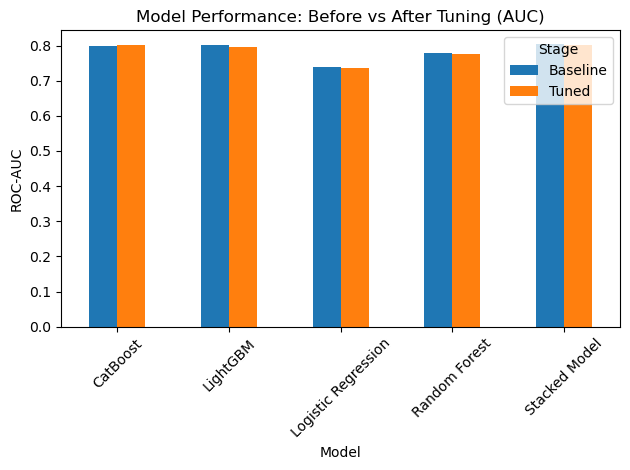

In [102]:
# Pivot AUC for comparison
auc_pivot = full_comparison_df.pivot_table(
    index='Model',
    columns='Stage',
    values='AUC'
)

# Plot
plt.figure(figsize=(8,5))
auc_pivot[['Baseline', 'Tuned']].plot(kind='bar')

plt.ylabel('ROC-AUC')
plt.title('Model Performance: Before vs After Tuning (AUC)')
plt.xticks(rotation=45)
plt.legend(title='Stage')

plt.tight_layout()
plt.show()

## Full Comparison of Tuned Models

<Figure size 1000x600 with 0 Axes>

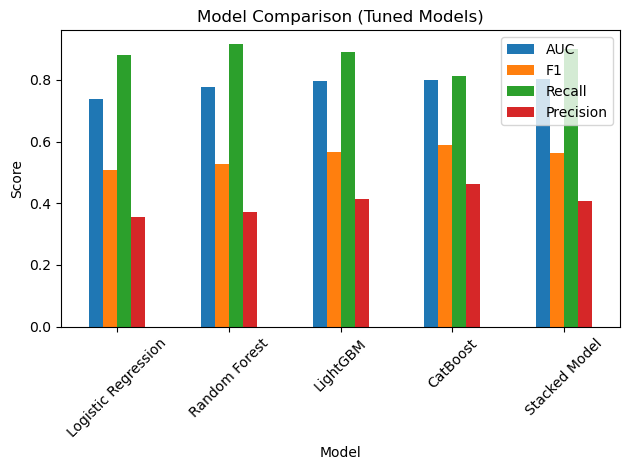

In [103]:
# Only tuned models
tuned_only_df = full_comparison_df[full_comparison_df['Stage'] == 'Tuned']

# Set index
tuned_only_df = tuned_only_df.set_index('Model')

# Plot all metrics
plt.figure(figsize=(10,6))
tuned_only_df[['AUC', 'F1', 'Recall', 'Precision']].plot(kind='bar')

plt.ylabel('Score')
plt.title('Model Comparison (Tuned Models)')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## Improvement Plot

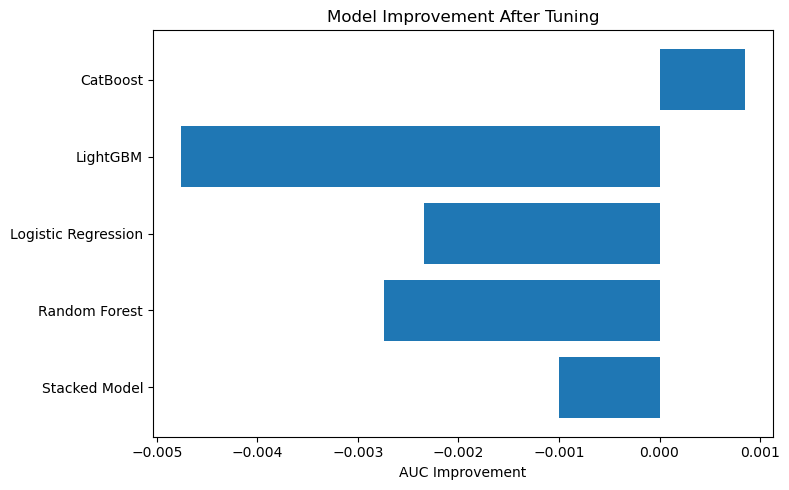

In [104]:
# Compute AUC improvement
auc_pivot['Improvement'] = auc_pivot['Tuned'] - auc_pivot['Baseline']

# Plot improvement
plt.figure(figsize=(8,5))
plt.barh(auc_pivot.index, auc_pivot['Improvement'])

plt.xlabel('AUC Improvement')
plt.title('Model Improvement After Tuning')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Stacked Model vs Others

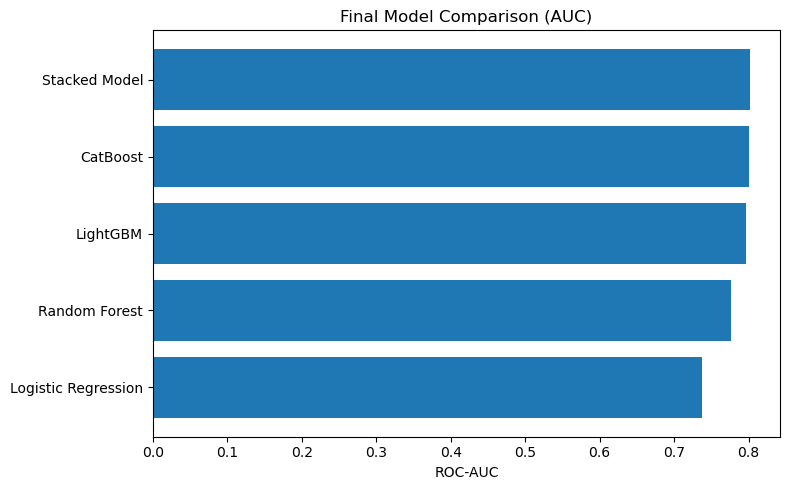

In [105]:
# Sort tuned models by AUC
tuned_sorted = tuned_only_df.sort_values(by='AUC', ascending=True)

plt.figure(figsize=(8,5))
plt.barh(tuned_sorted.index, tuned_sorted['AUC'])

plt.xlabel('ROC-AUC')
plt.title('Final Model Comparison (AUC)')
plt.tight_layout()

plt.savefig("../reports/figures/model_comparison_auc.png", dpi=300, bbox_inches='tight')
plt.show()

# Save Models

In [109]:
joblib.dump(rf_pipeline, "../models/baseline_rf.pkl")
joblib.dump(lgbm_pipeline, "../models/baseline_lgbm.pkl")
joblib.dump(cb_pipeline, "../models/baseline_cb.pkl")

['../models/baseline_cb.pkl']

# Save Stacking Metadata

In [110]:
stacked_metadata = {
    "threshold": 0.5 
}

joblib.dump(stacked_metadata, "../models/stacked_metadata.pkl")

['../models/stacked_metadata.pkl']